包导入，matplotlib中文支持

In [12]:
import numpy as np
import scipy.signal as signal
import scipy.linalg
import matplotlib.pyplot as plt

# matplotlib 中文支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

输入图片：mana.jpg（RGB → 灰度）
卷积核：高斯模糊核（9×9，σ = 1.5）
目标：在已知模糊核下，从「模糊 + 噪声」图像中反卷积恢复原图

图像尺寸 = (553, 526)
模糊后尺寸 = (561, 534)，带噪 SNR = 29.99 dB


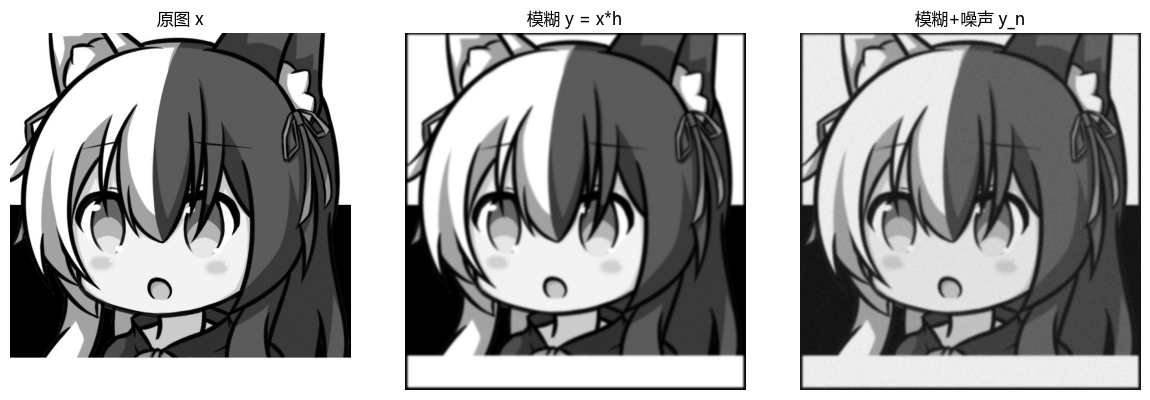

In [13]:
def snr_db(x, x_hat):
    """信噪比（dB）：SNR = 10*log10(||x||^2 / ||x - x_hat||^2)"""
    return 10 * np.log10(np.sum(x ** 2) / np.sum((x - x_hat) ** 2))


def gaussian_kernel(size, sigma):
    """生成归一化的二维高斯模糊核"""
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return k / k.sum()


def add_noise(sig, snr_target=30.0, seed=42):
    """添加高斯白噪声，使带噪信号 SNR 达到 snr_target (dB)"""
    rng = np.random.default_rng(seed)
    p_sig = np.mean(sig ** 2)
    p_noise = p_sig / (10 ** (snr_target / 10))
    return sig + rng.normal(0.0, np.sqrt(p_noise), sig.shape)


# ---- 输入图片：mana.jpg，转灰度并归一化到 [0,1] ----
rgb = plt.imread('mana.jpg')     # 与笔记本同目录
x = rgb.mean(axis=2)             # RGB → 灰度
print(f'图像尺寸 = {x.shape}')

# ---- 卷积核：9×9 高斯模糊，σ = 1.5 ----
h = gaussian_kernel(9, 1.5)

# ---- 模糊 + 噪声：y = x * h + n ----
y = signal.fftconvolve(x, h, mode='full')
y_n = add_noise(y, 30.0)
print(f'模糊后尺寸 = {y.shape}，带噪 SNR = {snr_db(y, y_n):.2f} dB')

# ---- 显示 原图 / 模糊 / 模糊+噪声 ----
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x, cmap='gray'); axes[0].set_title('原图 x'); axes[0].axis('off')
axes[1].imshow(y, cmap='gray'); axes[1].set_title('模糊 y = x*h'); axes[1].axis('off')
axes[2].imshow(y_n, cmap='gray'); axes[2].set_title('模糊+噪声 y_n'); axes[2].axis('off')
plt.tight_layout()
plt.show()

# 1. 直接频域相除
$$\hat{X}(\omega) = \frac{Y(\omega)}{H(\omega)}$$

直接频域相除：SNR = -99.44 dB


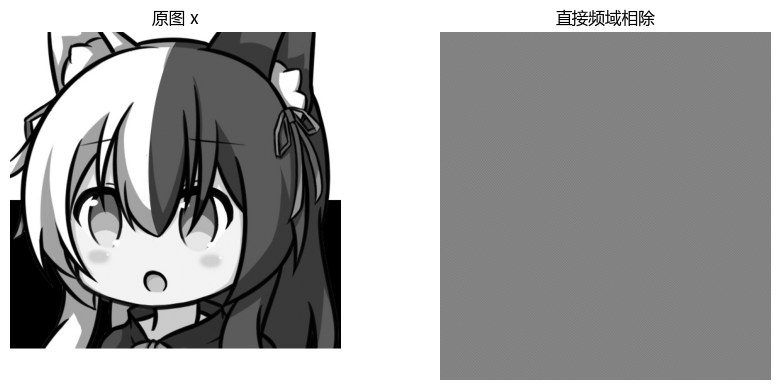

In [14]:
def deconv_direct2d(y, h, shape, eps=1e-8):
    """直接频域相除：X_hat = Y / H（二维）

    FFT 尺寸取不小于 len(y) 的 2 的幂；|H| 接近 0 处用阈值保护。
    """
    nfft = (1 << (y.shape[0] - 1).bit_length(),
            1 << (y.shape[1] - 1).bit_length())
    Y = np.fft.rfft2(y, s=nfft)
    H = np.fft.rfft2(h, s=nfft)
    thresh = eps * np.abs(H).max()
    H_safe = np.where(np.abs(H) > thresh, H, thresh)
    return np.fft.irfft2(Y / H_safe, s=nfft)[:shape[0], :shape[1]]


x1 = deconv_direct2d(y_n, h, x.shape)
print(f'直接频域相除：SNR = {snr_db(x, x1):.2f} dB')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(x, cmap='gray'); axes[0].set_title('原图 x'); axes[0].axis('off')
axes[1].imshow(x1, cmap='gray'); axes[1].set_title('直接频域相除'); axes[1].axis('off')
plt.tight_layout()
plt.show()

# 2. 维纳滤波
$$\hat{X}(\omega) = \left( \frac{H^*(\omega)}{\vert{}H(\omega)\vert{}^2 + K} \right) Y(\omega)$$

维纳滤波：SNR = 19.10 dB


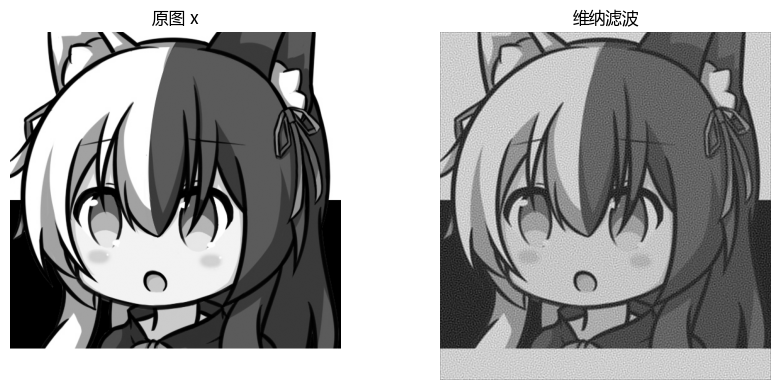

In [15]:
def deconv_wiener2d(y, h, shape, k=0.1):
    """维纳滤波：X_hat = conj(H)/(|H|^2 + K) * Y（二维）

    K 以 mean(|H|^2) 归一化，防止 |H| 接近 0 时放大噪声。
    """
    nfft = (1 << (y.shape[0] - 1).bit_length(),
            1 << (y.shape[1] - 1).bit_length())
    Y = np.fft.rfft2(y, s=nfft)
    H = np.fft.rfft2(h, s=nfft)
    K = k * np.mean(np.abs(H) ** 2)
    G = np.conj(H) / (np.abs(H) ** 2 + K)
    return np.fft.irfft2(G * Y, s=nfft)[:shape[0], :shape[1]]


x2 = deconv_wiener2d(y_n, h, x.shape)
print(f'维纳滤波：SNR = {snr_db(x, x2):.2f} dB')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(x, cmap='gray'); axes[0].set_title('原图 x'); axes[0].axis('off')
axes[1].imshow(x2, cmap='gray'); axes[1].set_title('维纳滤波'); axes[1].axis('off')
plt.tight_layout()
plt.show()

# 3. 时域构造核矩阵，用最小二乘法求解（小图块演示）
对二维图像，完整的卷积矩阵 $A$ 尺寸为 $N_y \times N_x$ 行 × $N_y \times N_x$ 列，整图不可行。
这里取中心 30×30 小图块演示，$A$ 为「双重块 Toeplitz」矩阵：
$$\min_x \Vert{}Ax - y\Vert{}_2^2 \Rightarrow \hat{x} = (A^T A)^{-1} A^T y$$

卷积矩阵 A 尺寸 = (1444, 900)
A @ x 与 y 的最大误差 = 8.53e-14
最小二乘（30×30 图块）：SNR = -73.03 dB


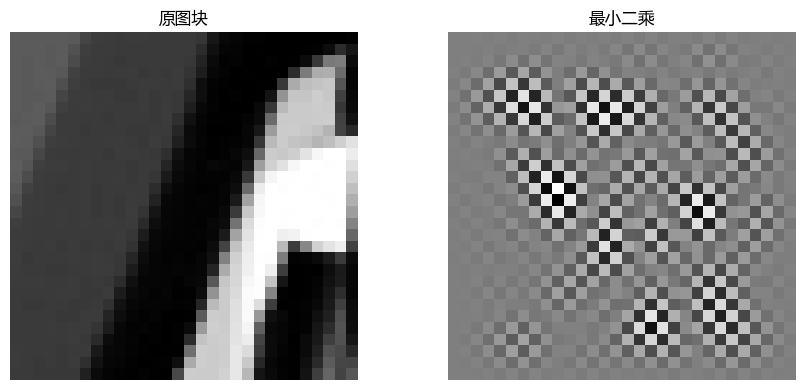

In [16]:
def conv_matrix2d(h2d, n_y_rows, n_x_rows, n_y_cols, n_x_cols):
    """由二维卷积核 h2d（k×k）构造「双重块 Toeplitz」卷积矩阵 A

    满足 vec(A @ X) = vec(conv2d(X, h2d, 'full'))，
    尺寸 (n_y_rows*n_y_cols) 行 × (n_x_rows*n_x_cols) 列。
    """
    k_rows, k_cols = h2d.shape
    blocks = []
    for i in range(n_y_rows):           # 块行 = 输出行索引
        row_blocks = []
        for j in range(n_x_rows):       # 块列 = 输入行索引
            d = i - j
            if 0 <= d < k_rows:
                # 卷积核第 d 行构成的 Toeplitz 块
                row_blocks.append(scipy.linalg.toeplitz(
                    np.concatenate([h2d[d], np.zeros(n_y_cols - k_cols)]),
                    np.concatenate([[h2d[d, 0]], np.zeros(n_x_cols - 1)])))
            else:
                row_blocks.append(np.zeros((n_y_cols, n_x_cols)))
        blocks.append(np.hstack(row_blocks))
    return np.vstack(blocks)


def deconv_ols2d(y_vec, A, shape):
    """普通最小二乘：x_hat = (A^T A)^{-1} A^T y"""
    x_hat, *_ = np.linalg.lstsq(A, y_vec, rcond=None)
    return x_hat.reshape(shape)


# ---- 取中心 30×30 小图块演示 ----
ps = 30                          # 图块边长
r0 = x.shape[0] // 2 - ps // 2
c0 = x.shape[1] // 2 - ps // 2
x_patch = x[r0:r0 + ps, c0:c0 + ps]
# 注意：y_patch 必须由 x_patch 重新卷积，不能从全长 y 中切片
y_patch = signal.fftconvolve(x_patch, h, mode='full')
y_patch_n = add_noise(y_patch, 30.0)

n_y = ps + h.shape[0] - 1        # 38
A = conv_matrix2d(h, n_y, ps, n_y, ps)
print(f'卷积矩阵 A 尺寸 = {A.shape}')

# 验证卷积矩阵与 fftconvolve 一致
err = np.abs(A @ x_patch.ravel() - y_patch.ravel()).max()
print(f'A @ x 与 y 的最大误差 = {err:.2e}')

x3 = deconv_ols2d(y_patch_n.ravel(), A, (ps, ps))
print(f'最小二乘（{ps}×{ps} 图块）：SNR = {snr_db(x_patch, x3):.2f} dB')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(x_patch, cmap='gray'); axes[0].set_title('原图块'); axes[0].axis('off')
axes[1].imshow(x3, cmap='gray'); axes[1].set_title('最小二乘'); axes[1].axis('off')
plt.tight_layout()
plt.show()

# 4. 岭回归 / Tikhonov 正则化（L2 正则化）
为了解决 $A^T A$ 不可逆和病态问题，在目标函数中加入 $L2$ 惩罚项：
$$\min_x \Vert{}Ax - y\Vert{}_2^2 + \lambda \Vert{}x\Vert{}_2^2 \Rightarrow \hat{x} = (A^T A + \lambda I)^{-1} A^T y$$

岭回归（30×30 图块）：SNR = 12.03 dB


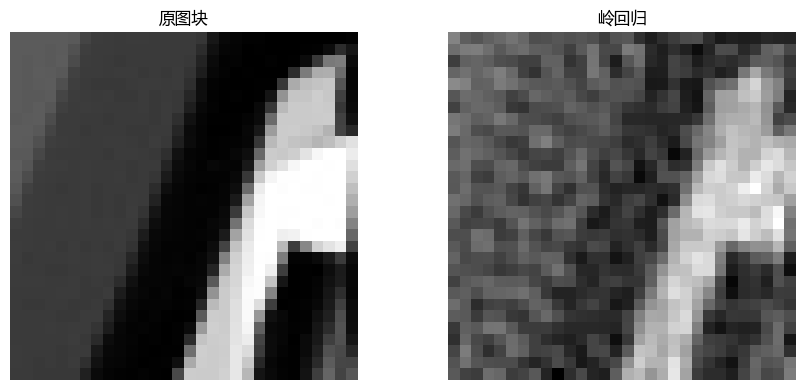

In [17]:
def deconv_ridge2d(y_vec, A, shape, lam):
    """岭回归：x_hat = (A^T A + λI)^{-1} A^T y"""
    ATA = A.T @ A
    x_hat = np.linalg.solve(ATA + lam * np.eye(ATA.shape[0]), A.T @ y_vec)
    return x_hat.reshape(shape)


# λ 以 trace(A^T A)/n 为单位归一化
scale = np.trace(A.T @ A) / (ps * ps)
lam = 0.01 * scale
x4 = deconv_ridge2d(y_patch_n.ravel(), A, (ps, ps), lam)
print(f'岭回归（{ps}×{ps} 图块）：SNR = {snr_db(x_patch, x4):.2f} dB')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(x_patch, cmap='gray'); axes[0].set_title('原图块'); axes[0].axis('off')
axes[1].imshow(x4, cmap='gray'); axes[1].set_title('岭回归'); axes[1].axis('off')
plt.tight_layout()
plt.show()

方法                  SNR (dB)
--------------------------------
直接频域相除                -99.44
维纳滤波                   19.10
最小二乘 OLS              -73.03
岭回归                    12.03


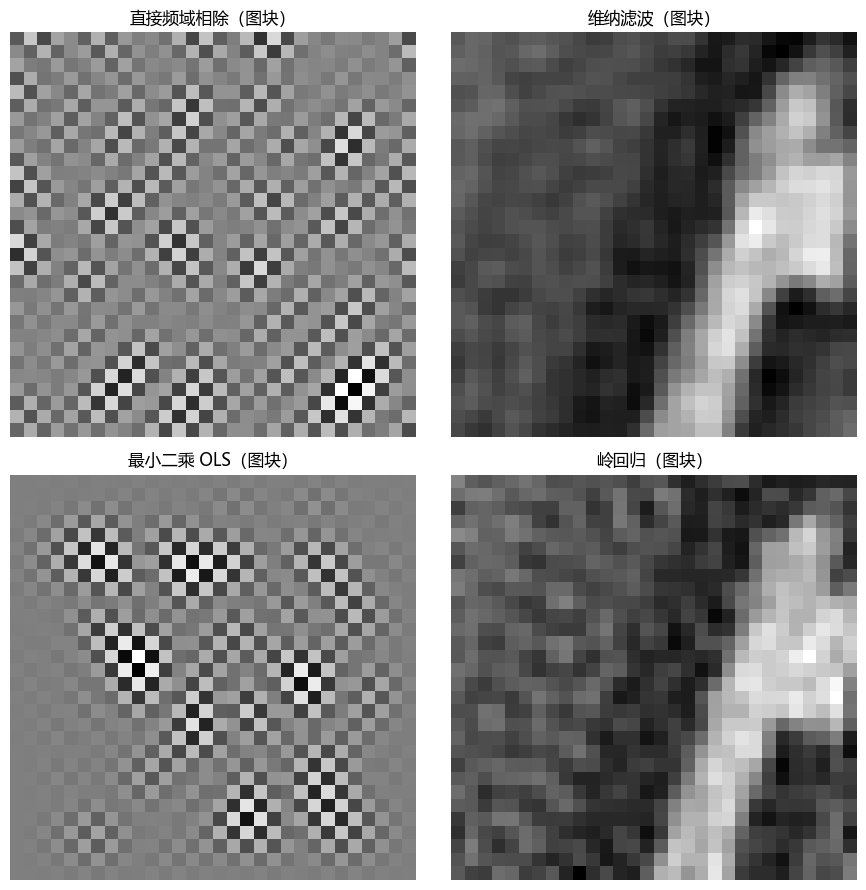

In [18]:
# ---- 各方法 SNR 汇总 ----
rows = [
    ('直接频域相除', snr_db(x, x1)),
    ('维纳滤波', snr_db(x, x2)),
    ('最小二乘 OLS', snr_db(x_patch, x3)),
    ('岭回归', snr_db(x_patch, x4)),
]
print('方法                  SNR (dB)')
print('-' * 32)
for name, snr in rows:
    print(f'{name:<18}{snr:>10.2f}')

# ---- 图块区域反卷积结果对比 ----
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, (x_hat, title) in zip(axes.ravel(), [
        (x1[r0:r0 + ps, c0:c0 + ps], '直接频域相除（图块）'),
        (x2[r0:r0 + ps, c0:c0 + ps], '维纳滤波（图块）'),
        (x3, '最小二乘 OLS（图块）'),
        (x4, '岭回归（图块）')]):
    ax.imshow(x_hat, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

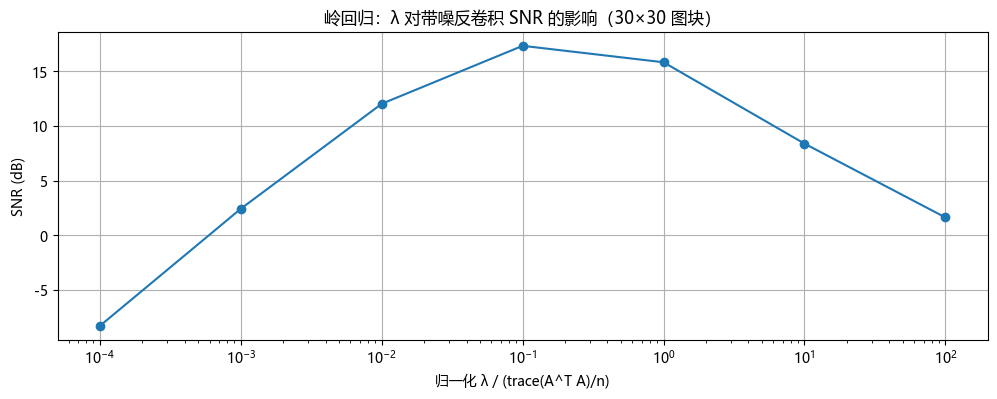

最优归一化 λ = 1.00e-01，SNR = 17.33 dB


In [19]:
# ---- 岭回归 λ 扫描：正则化强度对带噪反卷积的影响 ----
# λ 以 trace(A^T A)/n 为单位归一化，横轴展示归一化倍数
scale = np.trace(A.T @ A) / (ps * ps)

lams = np.logspace(-4, 2, 7)
snrs = [snr_db(x_patch, deconv_ridge2d(y_patch_n.ravel(), A, (ps, ps), lam * scale))
        for lam in lams]

plt.figure(figsize=(12, 4))
plt.semilogx(lams, snrs, 'o-')
plt.xlabel('归一化 λ / (trace(A^T A)/n)')
plt.ylabel('SNR (dB)')
plt.title('岭回归：λ 对带噪反卷积 SNR 的影响（30×30 图块）')
plt.grid(True)
plt.show()

best = int(np.argmax(snrs))
print(f'最优归一化 λ = {lams[best]:.2e}，SNR = {snrs[best]:.2f} dB')